# B — DR formula variant testing

The current preprocessing pipeline (`1-Data_preprocessing.ipynb`) computes the physics-based estimator `fwns_calculated` using the De Lannoy *Difference Ratio* formula:

$$
f_{\text{wns}} \;=\; \frac{\epsilon_{\text{land}}^{\text{ref}} - \epsilon_{\text{obs}}}{\epsilon_{\text{land}}^{\text{ref}} - \epsilon_{\text{water}}^{\text{ref}}}
$$

with a single fixed choice of frequency/polarization (`K_h` for both land slots, `19H` for the observed emissivity). Empirically this is not the best variant.

This notebook **systematically sweeps every combination** of the available frequency/polarization options for each emissivity slot and ranks the resulting estimators against the true `fwns` label, mirroring the baseline-evaluation style of `3-Model_training.ipynb` (Section 1).

**Sweep design**

The reference land emissivity LUT is only loaded for the K band in [1-Data_preprocessing.ipynb:140-141](1-Data_preprocessing.ipynb#L140) (`lut_de_lannoy_K_h.csv` / `lut_de_lannoy_K_v.csv`), so the land slots are restricted to K-band.

| Slot | Options | Count |
|---|---|---|
| Numerator land emissivity | `ref_land_emis_de_lannoy_K_{h,v}` | 2 |
| Denominator land emissivity | `ref_land_emis_de_lannoy_K_{h,v}` | 2 |
| Observed emissivity | `emiss{19,37}{H,V}_de_lannoy` | 4 |

→ **2 × 2 × 4 = 16 variants** (numerator and denominator land slots are swept independently).

**Open-water emissivity constant.** Only `REF_WATER_EMISS_H = 0.288760` is defined in the codebase. We reuse it for all 16 variants. The variant ranking is therefore measuring the effect of the land/obs swaps; the absolute metrics for V-pol-obs variants carry an additional caveat (the constant is not strictly the right one for V).

**Evaluation split.** January 1–10, 2017 (DOY 1–10), reduced window for fast iteration.

## 1. Imports and configuration

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import product
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

DATA_DIR = Path("data/datasets")
TEST_YEAR = 2017
DAY_RANGE = range(1, 366)   # DOY 1–365 = January 1–365
REF_WATER_EMISS_H = 0.288760

# Knob for fast iteration. Set to 1.0 for the final run.
SAMPLE_FRAC = 1.0
RANDOM_SEED = 0

# Reference land emissivity LUT is only loaded for K band in 1-Data_preprocessing.ipynb,
# so Ka-band ref_land variables do not exist in the parquet files.
LAND_COLS = [
    "ref_land_emis_de_lannoy_K_h",
    "ref_land_emis_de_lannoy_K_v",
]
OBS_COLS = [
    "emiss19H_de_lannoy",
    "emiss19V_de_lannoy",
    "emiss37H_de_lannoy",
    "emiss37V_de_lannoy",
]
NEEDED = sorted(set(LAND_COLS + OBS_COLS + ["fwns", "year", "day_of_year", "vsm", "VOD"]))

# Short tag helpers used in variant names: "K_h" -> "Kh", "emiss19H" -> "19H"
def land_tag(col):
    parts = col.split("_")  # ['ref','land','emis','de','lannoy','K','h']
    band, pol = parts[-2], parts[-1]
    return f"{band}{pol}"

def obs_tag(col):
    return col.replace("emiss", "").replace("_de_lannoy", "")

print(f"Land options: {[land_tag(c) for c in LAND_COLS]}")
print(f"Obs options:  {[obs_tag(c) for c in OBS_COLS]}")
print(f"Total variants: {len(LAND_COLS) * len(LAND_COLS) * len(OBS_COLS)}")

Land options: ['Kh', 'Kv']
Obs options:  ['19H', '19V', '37H', '37V']
Total variants: 16


## 2. Load the test split

Read only the columns we need from the first 10 daily parquet files of 2017 (January 1–10) and concatenate.

In [35]:
test_files = sorted(DATA_DIR.glob(f"windsat_{TEST_YEAR}_*.parquet"))[:365]  # first 365 DOY files
print(f"Using {len(test_files)} parquet files for year {TEST_YEAR} (DOY 1–365)")

frames = [pd.read_parquet(p, columns=NEEDED) for p in test_files]
df = pd.concat(frames, ignore_index=True)
del frames

# Keep only the target year and the first 10 days of January.
df = df[df["year"] == TEST_YEAR]
df = df[df["day_of_year"].isin(DAY_RANGE)]

# Drop rows with no ground truth.
df = df.dropna(subset=["fwns"])

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Loaded {len(df):,} rows  |  memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
display(df.head(3))

Using 362 parquet files for year 2017 (DOY 1–365)
Loaded 12,837,873 rows  |  memory: 564.9 MB


,VOD,day_of_year,emiss19H_de_lannoy,emiss19V_de_lannoy,emiss37H_de_lannoy,emiss37V_de_lannoy,fwns,ref_land_emis_de_lannoy_K_h,ref_land_emis_de_lannoy_K_v,vsm,year
0,0.212244,1.0,0.635044,0.791620,0.698915,0.830745,0.428428,0.825967,0.911706,0.500000,2017.0
1,0.307436,1.0,0.629181,0.792108,0.675736,0.822090,0.318115,0.886815,0.946425,0.363537,2017.0
2,0.303924,1.0,0.740245,0.847575,0.780900,0.871718,0.239406,0.886815,0.946425,0.324001,2017.0


## 3. Compute every variant of the DR formula

For each `(land_num, land_den, obs)` triple we compute

$$
\hat f = \frac{\epsilon_{\text{land}}^{\text{num}} - \epsilon_{\text{obs}}}{\epsilon_{\text{land}}^{\text{den}} - \text{REF\_WATER\_EMISS\_H}}
$$

Variant names follow the pattern `num=Kh|den=Kh|obs=19H` so we can group/sort by slot later. The original baseline is `num=Kh|den=Kh|obs=19H`.

In [36]:
# Cache the 4 denominator series (one per land-den option) so we don't recompute them 16 times each.
denoms = {
    land_den: (df[land_den] - REF_WATER_EMISS_H).where(
        (df[land_den] - REF_WATER_EMISS_H).abs() > 1e-9
    )
    for land_den in LAND_COLS
}

variant_specs = []   # list of (name, land_num, land_den, obs)
preds = {}           # name -> Series

for land_num, land_den, obs in product(LAND_COLS, LAND_COLS, OBS_COLS):
    name = f"num={land_tag(land_num)}|den={land_tag(land_den)}|obs={obs_tag(obs)}"
    pred = (df[land_num] - df[obs]) / denoms[land_den]
    preds[name] = pred.astype(np.float32)
    variant_specs.append((name, land_num, land_den, obs))

preds_df = pd.DataFrame(preds, index=df.index)
print(f"Computed {preds_df.shape[1]} variant predictions over {len(preds_df):,} rows")

ORIGINAL_VARIANT = f"num={land_tag('ref_land_emis_de_lannoy_K_h')}|den={land_tag('ref_land_emis_de_lannoy_K_h')}|obs={obs_tag('emiss19H_de_lannoy')}"
print(f"Original variant tag: {ORIGINAL_VARIANT}")

Computed 16 variant predictions over 12,837,873 rows
Original variant tag: num=Kh|den=Kh|obs=19H


## 3b. K-band reference land emissivity lookup tables

The De Lannoy LUT maps *(soil moisture bin, VWC bin)* → reference land emissivity at K band (18.7 GHz) for both polarizations. These are the two LUTs used in the numerator and denominator slots of every DR variant above.

In [37]:
lut_h = pd.read_csv("data/lookup_tables/lut_de_lannoy_K_h.csv", index_col=0)
lut_v = pd.read_csv("data/lookup_tables/lut_de_lannoy_K_v.csv", index_col=0)

print("K-band H-polarization LUT  (rows = soil moisture bins, cols = VWC bins)")
display(lut_h.style.format("{:.4f}").set_caption("lut_de_lannoy_K_h — reference land emissivity (H-pol)"))

print("\nK-band V-polarization LUT  (rows = soil moisture bins, cols = VWC bins)")
display(lut_v.style.format("{:.4f}").set_caption("lut_de_lannoy_K_v — reference land emissivity (V-pol)"))

K-band H-polarization LUT  (rows = soil moisture bins, cols = VWC bins)


,0.00-0.05,0.05-0.10,0.10-0.15,0.15-0.20,0.20-0.25,0.25-0.30,0.30-0.40,0.40-0.50,0.50-0.60,0.60-0.70,0.70-1.00
0.00-0.10,0.7819,0.8163,0.8490,0.8735,0.8908,0.9053,0.9191,0.9306,0.9363,0.9288,0.9412
0.10-0.20,0.8973,0.8497,0.8525,0.8695,0.8899,0.9006,0.9162,0.9288,0.9368,0.9432,0.9415
0.20-0.30,0.7786,0.8516,0.8573,0.8614,0.8759,0.8878,0.9006,0.9178,0.9329,0.9434,0.9458
0.30-0.40,nan,nan,0.7962,0.8650,0.8662,0.8643,0.8868,0.9072,0.9326,0.9394,0.9371
0.40-0.50,0.7616,nan,0.8387,nan,0.8260,0.8744,0.7798,0.9052,0.9393,nan,0.9373



K-band V-polarization LUT  (rows = soil moisture bins, cols = VWC bins)


,0.00-0.05,0.05-0.10,0.10-0.15,0.15-0.20,0.20-0.25,0.25-0.30,0.30-0.40,0.40-0.50,0.50-0.60,0.60-0.70,0.70-1.00
0.00-0.10,0.9603,0.9575,0.9568,0.9577,0.9583,0.9594,0.9590,0.9557,0.9519,0.9405,0.9449
0.10-0.20,0.9937,0.9514,0.9500,0.9521,0.9561,0.9570,0.9580,0.9575,0.9564,0.9551,0.9479
0.20-0.30,0.9583,0.9611,0.9473,0.9517,0.9504,0.9525,0.9537,0.9570,0.9610,0.9632,0.9577
0.30-0.40,nan,nan,0.9090,0.9532,0.9488,0.9378,0.9464,0.9537,0.9602,0.9598,0.9439
0.40-0.50,0.9534,nan,0.9189,nan,0.9117,0.9409,0.8824,0.9438,0.9579,nan,0.9440


## 3c. Input distributions: vsm, VOD, and reference emissivities

Histograms of the main geophysical input variables for the January 2017 subset, giving a sense of the environmental conditions under which the DR formula is being evaluated.

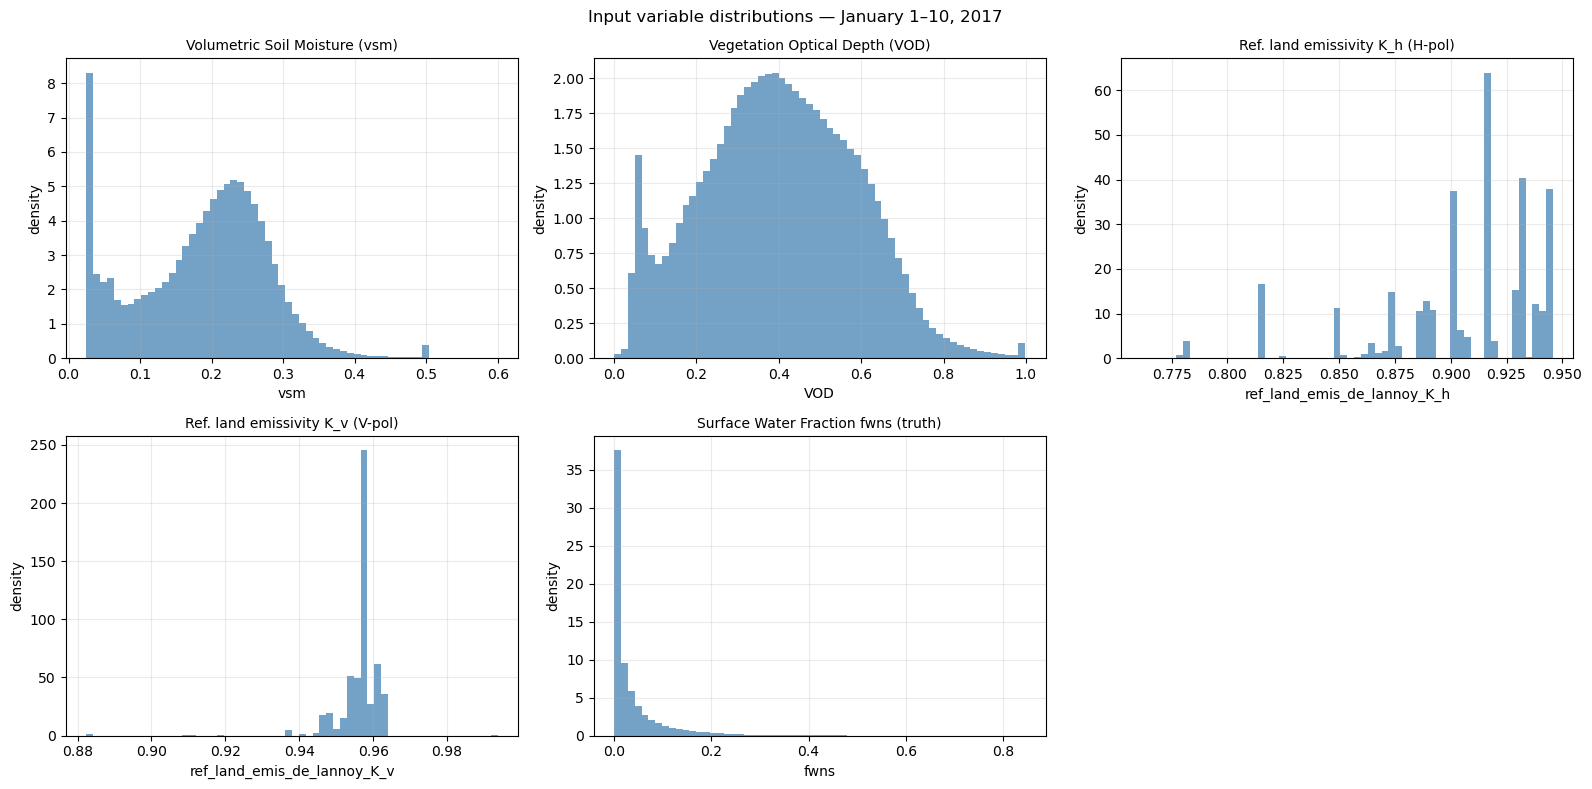

In [38]:
plot_vars = [
    ("vsm",                        "Volumetric Soil Moisture (vsm)"),
    ("VOD",                        "Vegetation Optical Depth (VOD)"),
    ("ref_land_emis_de_lannoy_K_h", "Ref. land emissivity K_h (H-pol)"),
    ("ref_land_emis_de_lannoy_K_v", "Ref. land emissivity K_v (V-pol)"),
    ("fwns",                        "Surface Water Fraction fwns (truth)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()

for ax, (col, title) in zip(axes_flat, plot_vars):
    series = df[col].dropna()
    ax.hist(series, bins=60, density=True, color="steelblue", alpha=0.75, edgecolor="none")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.grid(alpha=0.25)

axes_flat[-1].axis("off")  # 6th panel unused
plt.suptitle("Input variable distributions — January 1–10, 2017", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Compute metrics for every variant

Same metric block as `3-Model_training.ipynb`, Section 1: MAE, RMSE, R², bias. We additionally report:

- `MAE_clip / RMSE_clip / R2_clip`: same metrics on `pred.clip(0, 1)` — useful because the raw DR ratio can fall outside `[0, 1]`.
- `frac_in_range`: fraction of predictions that already fall within `[0, 1]`.

NaN/inf rows are dropped pairwise per variant before computing.

In [39]:
y_true_full = df["fwns"].to_numpy()

def pol_of_land(land_col):
    return land_col[-1].upper()  # 'h' or 'v' -> 'H'/'V'

rows = []
for name, land_num, land_den, obs in variant_specs:
    pred = preds_df[name].to_numpy()
    mask = np.isfinite(pred) & np.isfinite(y_true_full)
    yt = y_true_full[mask]
    yp = pred[mask]

    mae  = mean_absolute_error(yt, yp)
    rmse = root_mean_squared_error(yt, yp)
    r2   = r2_score(yt, yp)
    bias = float((yp - yt).mean())

    yp_c = np.clip(yp, 0.0, 1.0)
    mae_c  = mean_absolute_error(yt, yp_c)
    rmse_c = root_mean_squared_error(yt, yp_c)
    r2_c   = r2_score(yt, yp_c)

    frac_in_range = float(((yp >= 0.0) & (yp <= 1.0)).mean())

    rows.append({
        "variant": name,
        "land_num": land_tag(land_num),
        "land_den": land_tag(land_den),
        "obs": obs_tag(obs),
        "land_num_pol": pol_of_land(land_num),
        "land_den_pol": pol_of_land(land_den),
        "obs_freq": obs_tag(obs)[:2],   # '19' or '37'
        "obs_pol":  obs_tag(obs)[-1],   # 'H' or 'V'
        "tied_land": land_num == land_den,
        "MAE":  mae,  "RMSE":  rmse,  "R2":  r2,  "bias": bias,
        "MAE_clip": mae_c, "RMSE_clip": rmse_c, "R2_clip": r2_c,
        "frac_in_range": frac_in_range,
        "n_valid": int(mask.sum()),
    })

results_df = pd.DataFrame(rows).set_index("variant")
print(f"results_df: {results_df.shape}")
results_df.head(3)

results_df: (16, 17)


,land_num,land_den,obs,land_num_pol,land_den_pol,obs_freq,obs_pol,tied_land,MAE,RMSE,R2,bias,MAE_clip,RMSE_clip,R2_clip,frac_in_range,n_valid
variant,,,,,,,,,,,,,,,,,
num=Kh|den=Kh|obs=19H,Kh,Kh,19H,H,H,19,H,True,0.037321,0.050518,0.266408,-0.025213,0.019335,0.037714,0.591146,0.420551,12837873
num=Kh|den=Kh|obs=19V,Kh,Kh,19V,H,H,19,V,True,0.106561,0.138147,-4.485960,-0.106308,0.031737,0.060674,-0.058209,0.117693,12837873
num=Kh|den=Kh|obs=37H,Kh,Kh,37H,H,H,37,H,True,0.045872,0.061649,-0.092508,-0.035301,0.021842,0.042512,0.480500,0.388231,12837873


## 5. Ranking and sanity check

Sort all 16 variants by RMSE. The original baseline (`num=Kh|den=Kh|obs=19H`) is highlighted as the reference.

**Sanity check.** Notebook 3's physics baseline (full 2018 split) reported approximately:

| Metric | Value |
|---|---|
| MAE  | 0.0346 |
| RMSE | 0.0531 |
| R²   | 0.776  |
| bias | 0.0095 |

Our `ORIGINAL_VARIANT` row may differ slightly because this evaluation uses only January 1–10, 2017. A noticeable deviation from the expected ordering (not absolute values) would indicate a column-selection or NaN-masking bug above.

In [40]:
ranked = results_df.sort_values("RMSE")

print("=== Original baseline ===")
print(results_df.loc[[ORIGINAL_VARIANT], ["MAE", "RMSE", "R2", "bias", "frac_in_range"]].T)

print("\n=== All 16 variants ranked by RMSE ===")
display_cols = ["MAE", "RMSE", "R2", "bias", "frac_in_range",
                "MAE_clip", "RMSE_clip", "R2_clip"]
print(ranked[display_cols].round(5).to_string())

best = ranked.index[0]
orig = results_df.loc[ORIGINAL_VARIANT]
top  = results_df.loc[best]
print("\n=== Best vs Original ===")
print(f"Best     : {best}")
print(f"           MAE={top['MAE']:.5f}  RMSE={top['RMSE']:.5f}  R2={top['R2']:.5f}  bias={top['bias']:+.5f}")
print(f"Original : {ORIGINAL_VARIANT}")
print(f"           MAE={orig['MAE']:.5f}  RMSE={orig['RMSE']:.5f}  R2={orig['R2']:.5f}  bias={orig['bias']:+.5f}")
print(f"Δ RMSE   : {top['RMSE'] - orig['RMSE']:+.5f}  ({(top['RMSE']/orig['RMSE'] - 1)*100:+.1f}%)")


=== Original baseline ===
variant        num=Kh|den=Kh|obs=19H
MAE                         0.037321
RMSE                        0.050518
R2                          0.266408
bias                       -0.025213
frac_in_range               0.420551

=== All 16 variants ranked by RMSE ===
                           MAE     RMSE       R2     bias  frac_in_range  MAE_clip  RMSE_clip  R2_clip
variant                                                                                               
num=Kv|den=Kv|obs=19V  0.02736  0.04303  0.46775 -0.02131        0.59207   0.01880    0.03783  0.58869
num=Kv|den=Kh|obs=19V  0.02780  0.04323  0.46271 -0.02058        0.59207   0.01797    0.03577  0.63224
num=Kv|den=Kh|obs=37V  0.02937  0.04646  0.37943 -0.01611        0.64685   0.02230    0.04224  0.48717
num=Kv|den=Kv|obs=37V  0.02896  0.04662  0.37529 -0.01742        0.64685   0.02272    0.04349  0.45642
num=Kh|den=Kv|obs=19H  0.03532  0.04790  0.34052 -0.02610        0.42055   0.01895    0.03685 

## 6. Tied-land subset — 2×4 heatmap

The 8 variants where `land_num == land_den` are the physically coherent subset (the formula is derived from a two-endmember mixing model with a single land endmember). The heatmap below shows RMSE / MAE / R² for each `(land, obs)` combination — this is the headline figure for choosing a replacement for `fwns_calculated`.

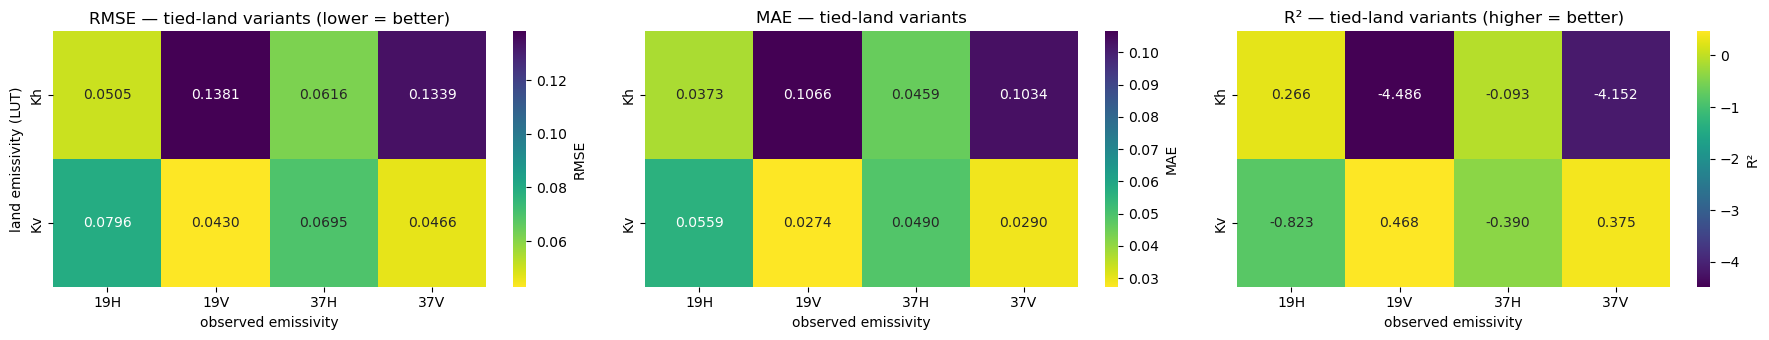

In [41]:
tied = results_df[results_df["tied_land"]].copy()
tied["land"] = tied["land_num"]

land_order = ["Kh", "Kv"]
obs_order  = ["19H", "19V", "37H", "37V"]

heat_rmse = tied.pivot(index="land", columns="obs", values="RMSE").reindex(index=land_order, columns=obs_order)
heat_mae  = tied.pivot(index="land", columns="obs", values="MAE" ).reindex(index=land_order, columns=obs_order)
heat_r2   = tied.pivot(index="land", columns="obs", values="R2"  ).reindex(index=land_order, columns=obs_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5))

sns.heatmap(heat_rmse, annot=True, fmt=".4f", cmap="viridis_r", ax=axes[0], cbar_kws={"label": "RMSE"})
axes[0].set_title("RMSE — tied-land variants (lower = better)")
axes[0].set_xlabel("observed emissivity")
axes[0].set_ylabel("land emissivity (LUT)")

sns.heatmap(heat_mae, annot=True, fmt=".4f", cmap="viridis_r", ax=axes[1], cbar_kws={"label": "MAE"})
axes[1].set_title("MAE — tied-land variants")
axes[1].set_xlabel("observed emissivity")
axes[1].set_ylabel("")

sns.heatmap(heat_r2, annot=True, fmt=".3f", cmap="viridis", ax=axes[2], cbar_kws={"label": "R²"})
axes[2].set_title("R² — tied-land variants (higher = better)")
axes[2].set_xlabel("observed emissivity")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. Full 16-variant ranking — bar plot

Bars are sorted by RMSE; bar colors mark whether `land_num == land_den` (i.e. the tied-vs-untied subset). The original baseline is annotated with a red marker. This view answers two questions:

1. Are any untied combinations meaningfully better than the best tied one?
2. Where does the original variant rank among the 16?

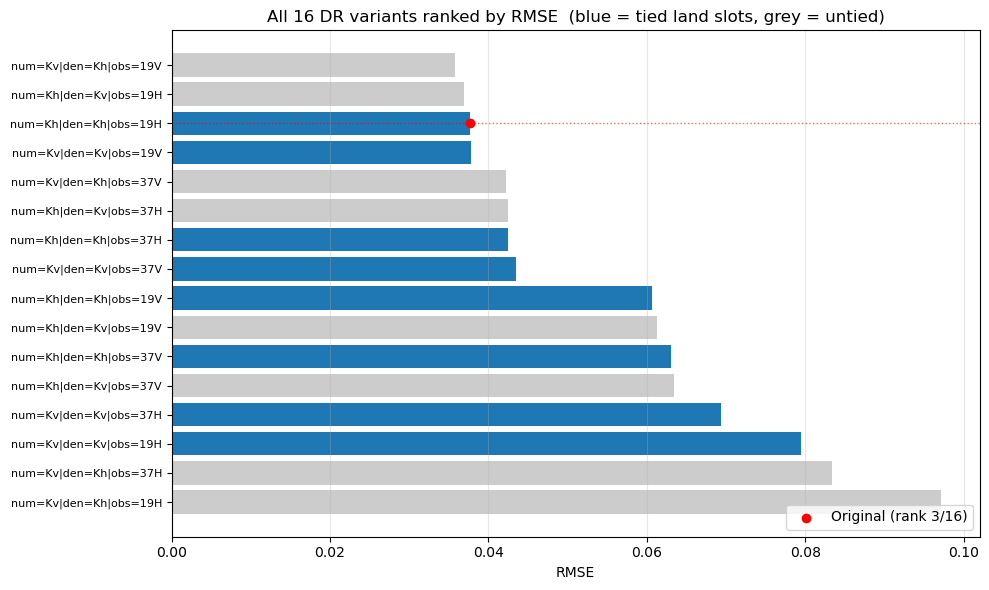

In [49]:
ranked = results_df.sort_values("RMSE_clip")
colors = np.where(ranked["tied_land"], "#1f77b4", "#cccccc")

fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(ranked))
ax.barh(ypos, ranked["RMSE_clip"].values, color=colors, edgecolor="none")
ax.set_yticks(ypos)
ax.set_yticklabels(ranked.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("RMSE")
ax.set_title("All 16 DR variants ranked by RMSE  (blue = tied land slots, grey = untied)")

orig_pos = ranked.index.get_loc(ORIGINAL_VARIANT)
ax.axhline(orig_pos, color="red", linestyle=":", linewidth=1, alpha=0.6)
ax.scatter([ranked.iloc[orig_pos]["RMSE_clip"]], [orig_pos], color="red", zorder=5,
           label=f"Original (rank {orig_pos + 1}/{len(ranked)})")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Distribution comparison — truth vs original / best / worst

Histograms (KDE-overlaid) of the predicted `fwns` for three reference variants compared with the ground-truth distribution. A good variant should reproduce both the spike near 0 (mostly-land pixels) and the heavy upper tail toward 1.

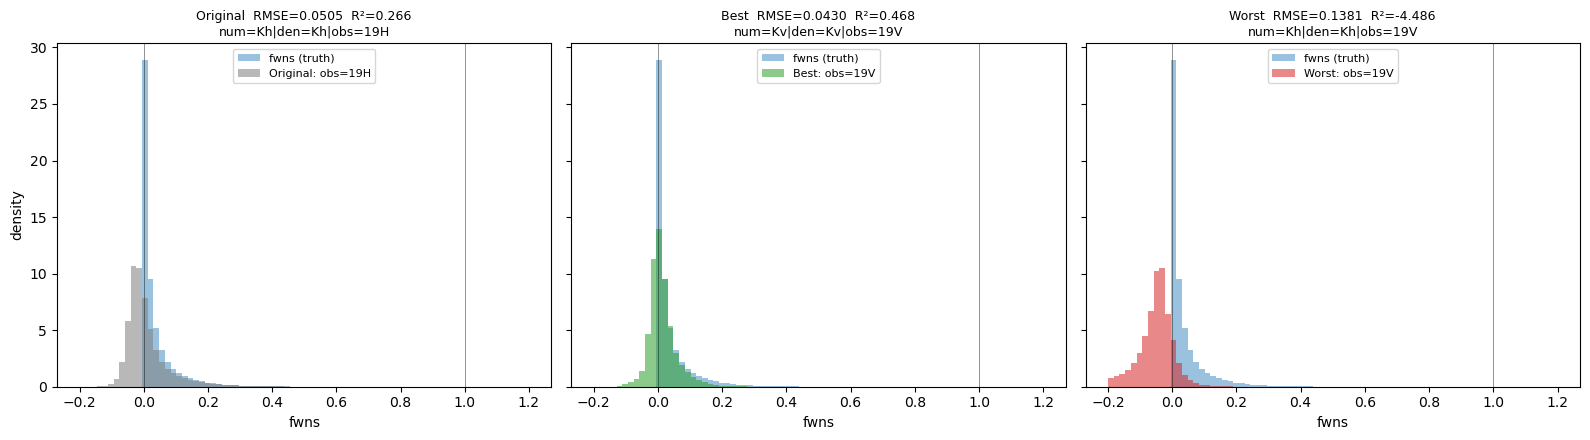

In [43]:
best_variant  = ranked.index[0]
worst_variant = ranked.index[-1]

picks = [
    ("Original", ORIGINAL_VARIANT, "#7f7f7f"),
    ("Best",     best_variant,     "#2ca02c"),
    ("Worst",    worst_variant,    "#d62728"),
]

bins = np.linspace(-0.2, 1.2, 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
y_true_arr = df["fwns"].to_numpy()

for ax, (label, variant, color) in zip(axes, picks):
    pred = preds_df[variant].to_numpy()
    pred = pred[np.isfinite(pred)]
    ax.hist(y_true_arr, bins=bins, density=True, alpha=0.45, color="#1f77b4", label="fwns (truth)")
    ax.hist(pred,        bins=bins, density=True, alpha=0.55, color=color,    label=f"{label}: {variant.split('|')[-1]}")
    ax.axvline(0.0, color="black", linewidth=0.6, alpha=0.5)
    ax.axvline(1.0, color="black", linewidth=0.6, alpha=0.5)
    m = results_df.loc[variant]
    ax.set_title(f"{label}  RMSE={m['RMSE']:.4f}  R²={m['R2']:.3f}\n{variant}", fontsize=9)
    ax.set_xlabel("fwns")
    ax.legend(loc="upper center", fontsize=8)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

## 9. Residual histograms — original vs best

Same visual style as the physics-baseline diagnostics in `3-Model_training.ipynb`, Section 1: histogram of residuals (predicted − truth) with a vertical line at 0 and the bias annotated.

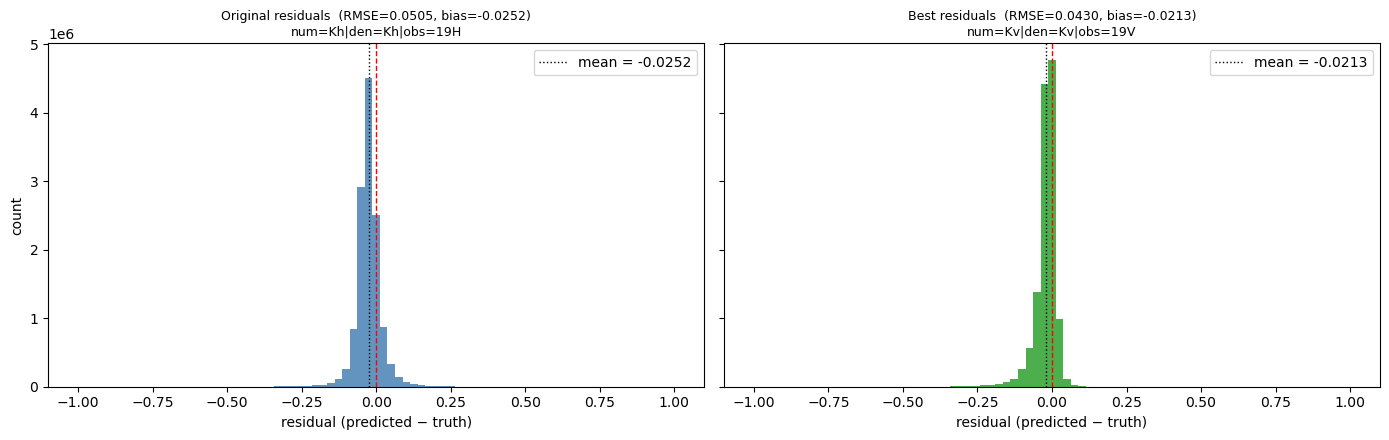

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
res_bins = np.linspace(-1.0, 1.0, 80)

for ax, (label, variant, color) in zip(axes, [("Original", ORIGINAL_VARIANT, "steelblue"),
                                              ("Best",     best_variant,     "#2ca02c")]):
    pred = preds_df[variant].to_numpy()
    mask = np.isfinite(pred)
    residuals = pred[mask] - y_true_arr[mask]
    bias = float(residuals.mean())
    rmse = results_df.loc[variant, "RMSE"]

    ax.hist(residuals, bins=res_bins, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(0.0, color="red", linestyle="--", linewidth=1)
    ax.axvline(bias, color="black", linestyle=":", linewidth=1, label=f"mean = {bias:+.4f}")
    ax.set_title(f"{label} residuals  (RMSE={rmse:.4f}, bias={bias:+.4f})\n{variant}", fontsize=9)
    ax.set_xlabel("residual (predicted − truth)")
    ax.legend()

axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

## 10. Scatter plots — predicted vs truth

5 000-row random samples per panel (same approach as `3-Model_training.ipynb`'s baseline scatter). Closeness to the 1:1 line indicates a good DR variant.

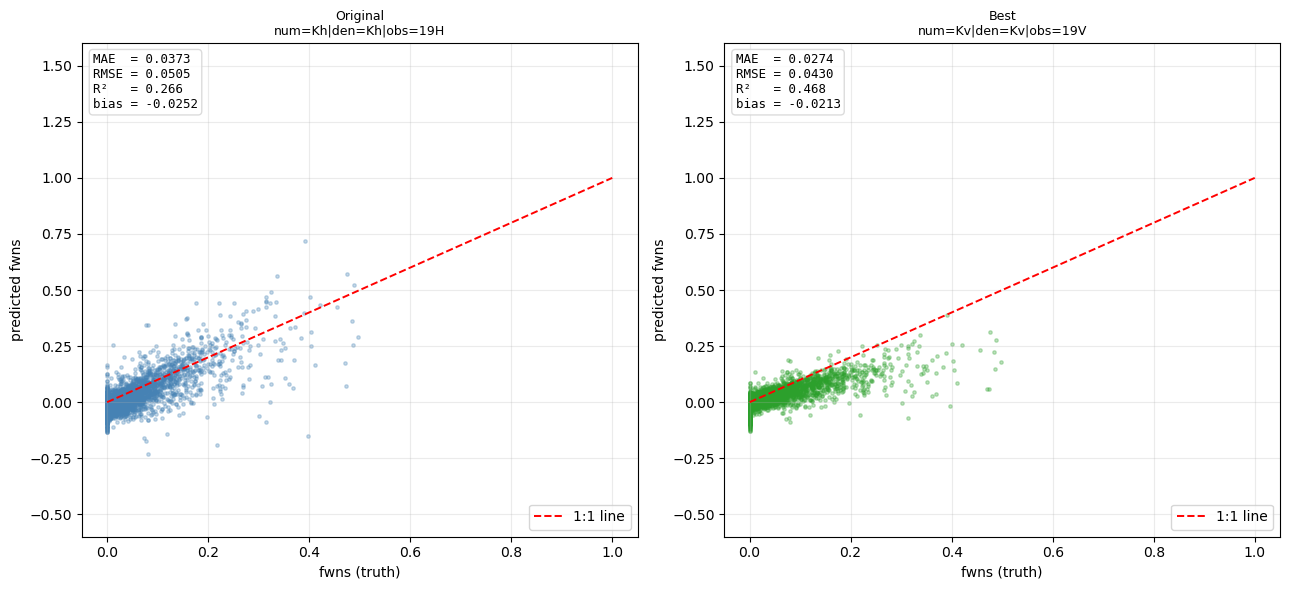

In [45]:
rng = np.random.default_rng(RANDOM_SEED)
sample_size = min(5000, len(df))
sample_idx = rng.choice(len(df), size=sample_size, replace=False)
y_sample = y_true_arr[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (label, variant, color) in zip(axes, [("Original", ORIGINAL_VARIANT, "steelblue"),
                                              ("Best",     best_variant,     "#2ca02c")]):
    pred_sample = preds_df[variant].to_numpy()[sample_idx]
    m = results_df.loc[variant]
    ax.scatter(y_sample, pred_sample, alpha=0.3, s=6, color=color)
    ax.plot([0, 1], [0, 1], "r--", linewidth=1.4, label="1:1 line")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.6, 1.6)
    ax.set_xlabel("fwns (truth)")
    ax.set_ylabel("predicted fwns")
    ax.set_title(f"{label}\n{variant}", fontsize=9)
    ax.text(0.02, 0.98,
            f"MAE  = {m['MAE']:.4f}\nRMSE = {m['RMSE']:.4f}\nR²   = {m['R2']:.3f}\nbias = {m['bias']:+.4f}",
            transform=ax.transAxes, va="top", ha="left",
            fontsize=9, family="monospace",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="lightgrey"))
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 11. Group-level summaries

Average each metric over all variants that share a given slot value. This separates the *driver* of any improvement: is it polarization, frequency, or whether the land slots are tied?

In [46]:
metric_cols = ["MAE", "RMSE", "R2", "bias"]

print("=== Mean metrics by observed-emissivity polarization ===")
print(results_df.groupby("obs_pol")[metric_cols].mean().round(5).to_string())

print("\n=== Mean metrics by observed-emissivity frequency ===")
print(results_df.groupby("obs_freq")[metric_cols].mean().round(5).to_string())

print("\n=== Mean metrics by numerator land polarization ===")
print(results_df.groupby("land_num_pol")[metric_cols].mean().round(5).to_string())

print("\n=== Mean metrics: tied vs untied land slots ===")
print(results_df.groupby("tied_land")[metric_cols].mean().round(5).to_string())

print("\n=== Mean metrics by polarization match (land_num vs obs) ===")
results_df_aug = results_df.assign(pol_match=(results_df["land_num_pol"] == results_df["obs_pol"]))
print(results_df_aug.groupby("pol_match")[metric_cols].mean().round(5).to_string())

=== Mean metrics by observed-emissivity polarization ===
             MAE     RMSE       R2     bias
obs_pol                                    
H        0.04875  0.06851 -0.42392  0.01007
V        0.06442  0.08649 -1.65898 -0.05924

=== Mean metrics by observed-emissivity frequency ===
              MAE     RMSE       R2     bias
obs_freq                                    
19        0.05671  0.07767 -1.09265 -0.02330
37        0.05647  0.07733 -0.99025 -0.02587

=== Mean metrics by numerator land polarization ===
                  MAE     RMSE      R2     bias
land_num_pol                                   
H             0.07047  0.09134 -1.8013 -0.06496
V             0.04271  0.06366 -0.2816  0.01580

=== Mean metrics: tied vs untied land slots ===
               MAE     RMSE      R2     bias
tied_land                                   
False      0.05638  0.07712 -0.9787 -0.02210
True       0.05679  0.07788 -1.1042 -0.02707

=== Mean metrics by polarization match (land_num vs obs) 

## 12. Conclusion

Read the printed comparison in **Section 5** ("Best vs Original") and the heatmap in **Section 6** to identify the winning variant.

If the best tied-land variant materially improves over the original `(num=Kh|den=Kh|obs=19H)`, the recommendation is to update the formula in `1-Data_preprocessing.ipynb` at the two locations where `fwns_calculated` is computed and re-export the parquet dataset:

- [1-Data_preprocessing.ipynb:2989](1-Data_preprocessing.ipynb#L2989) — augmented dataset cell
- [1-Data_preprocessing.ipynb:3343](1-Data_preprocessing.ipynb#L3343) — per-day pipeline cell

The same change should also be reflected in the `denominator`, `term_1`, `term_2` derived columns (lines [2986-2988](1-Data_preprocessing.ipynb#L2986) and [3340-3342](1-Data_preprocessing.ipynb#L3340)), since notebook 3 uses them as features in the model-training feature blocks.

**Caveat to keep in mind.** The open-water emissivity constant `REF_WATER_EMISS_H = 0.288760` is strictly valid for 18.7 GHz, H polarization. Variants whose denominator pairs a 37 GHz / V-pol land emissivity with this H-pol water constant are physically inconsistent. They may still rank well empirically (because the constant is buried inside a difference and acts mostly as an offset/scale), but a future iteration of this analysis should source matching `REF_WATER_EMISS_{V, Ka_h, Ka_v}` values from De Lannoy et al. 2016 Table 2 and re-run the sweep.

## 13. ML comparison — LinearRegression vs XGBoost per DR variant (32 models)

For each of the 16 DR variant predictions, fit both a **LinearRegression** and an **XGBoost** regressor using **only that variant's values as a single input feature** (shape `(N, 1)`).

- **Training set**: every even-indexed valid row.
- **Test set**: every odd-indexed valid row.

This produces **32 models total** (2 model types × 16 variants) and shows whether a simple 1-D calibration — or a non-linear one — can recover accuracy on top of each physics-based estimate.

In [47]:
from sklearn.linear_model import LinearRegression
import xgboost as xgb

y_all   = df["fwns"].to_numpy(dtype=np.float32)
valid_y = np.isfinite(y_all)
valid_positions = np.where(valid_y)[0]

train_idx = valid_positions[::2]   # even positions among valid rows → train
test_idx  = valid_positions[1::2]  # odd positions                   → test

ml_rows = []

for variant_name in preds_df.columns:
    x_raw = preds_df[variant_name].to_numpy(dtype=np.float32)
    valid  = np.isfinite(x_raw) & valid_y

    tr = train_idx[np.isin(train_idx, np.where(valid)[0])]
    te = test_idx [np.isin(test_idx,  np.where(valid)[0])]

    X_tr = x_raw[tr].reshape(-1, 1)
    X_te = x_raw[te].reshape(-1, 1)
    y_tr = y_all[tr]
    y_te = y_all[te]

    for model_name, model in [
        ("LinearRegression", LinearRegression()),
        ("XGBoost", xgb.XGBRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, random_state=RANDOM_SEED, n_jobs=-1, verbosity=0
        )),
    ]:
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        ml_rows.append({
            "variant": variant_name,
            "model":   model_name,
            "MAE":     mean_absolute_error(y_te, pred),
            "RMSE":    root_mean_squared_error(y_te, pred),
            "R2":      r2_score(y_te, pred),
            "bias":    float((pred - y_te).mean()),
        })

ml_df = pd.DataFrame(ml_rows)
print(f"Train rows: {len(tr):,}  |  Test rows: {len(te):,}\n")
display(ml_df.sort_values("RMSE")[["variant", "model", "MAE", "RMSE", "R2", "bias"]].round(5).reset_index(drop=True))


Train rows: 6,418,937  |  Test rows: 6,418,936



,variant,model,MAE,RMSE,R2,bias
0,num=Kv|den=Kh|obs=19V,XGBoost,0.01825,0.03267,0.69338,0.00000
1,num=Kv|den=Kv|obs=19V,XGBoost,0.01845,0.03303,0.68647,0.00000
2,num=Kh|den=Kh|obs=19H,XGBoost,0.01937,0.03417,0.66446,-0.00001
3,num=Kh|den=Kv|obs=19H,XGBoost,0.01946,0.03434,0.66109,-0.00001
4,num=Kh|den=Kh|obs=19H,LinearRegression,0.02169,0.03594,0.62874,-0.00001
5,num=Kh|den=Kv|obs=19H,LinearRegression,0.02165,0.03597,0.62823,-0.00001
6,num=Kv|den=Kv|obs=19V,LinearRegression,0.02411,0.03735,0.59915,-0.00000
7,num=Kv|den=Kh|obs=19V,LinearRegression,0.02437,0.03775,0.59049,-0.00001
8,num=Kh|den=Kh|obs=37H,XGBoost,0.02273,0.03896,0.56391,-0.00000
9,num=Kh|den=Kv|obs=37H,XGBoost,0.02293,0.03932,0.55577,-0.00000


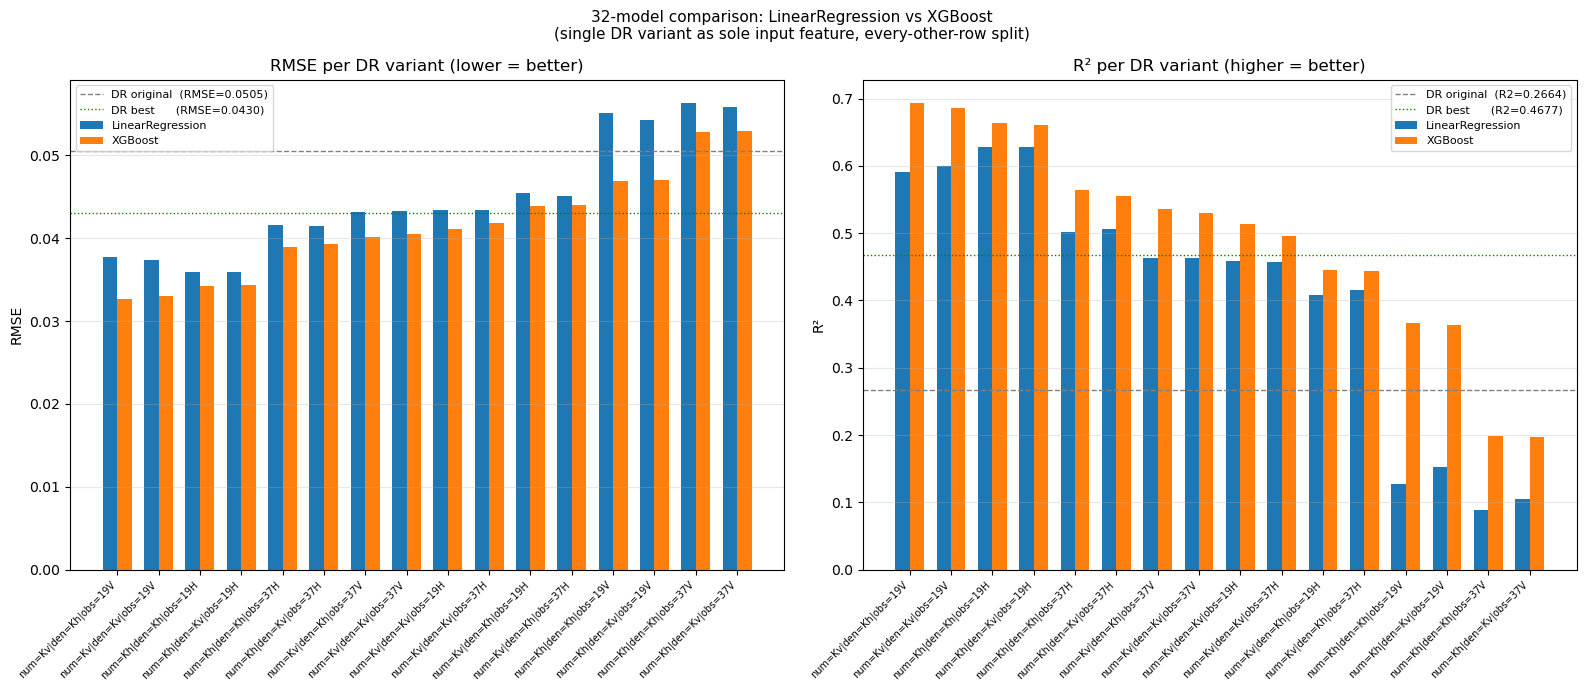

In [48]:
pivot_rmse = ml_df.pivot(index="variant", columns="model", values="RMSE").sort_values("XGBoost")
pivot_r2   = ml_df.pivot(index="variant", columns="model", values="R2").reindex(pivot_rmse.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

x = np.arange(len(pivot_rmse))
w = 0.35

for ax, pivot, ylabel, title, ref_col in [
    (axes[0], pivot_rmse, "RMSE", "RMSE per DR variant (lower = better)", "RMSE"),
    (axes[1], pivot_r2,   "R²",   "R² per DR variant (higher = better)",  "R2"),
]:
    ax.bar(x - w/2, pivot["LinearRegression"], w, label="LinearRegression", color="#1f77b4")
    ax.bar(x + w/2, pivot["XGBoost"],          w, label="XGBoost",          color="#ff7f0e")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    orig_val = results_df.loc[ORIGINAL_VARIANT, ref_col]
    best_val = results_df.sort_values("RMSE").iloc[0][ref_col]
    ax.axhline(orig_val, color="grey",  linestyle="--", linewidth=1, label=f"DR original  ({ref_col}={orig_val:.4f})")
    ax.axhline(best_val, color="green", linestyle=":",  linewidth=1, label=f"DR best      ({ref_col}={best_val:.4f})")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("32-model comparison: LinearRegression vs XGBoost\n(single DR variant as sole input feature, every-other-row split)",
             fontsize=11)
plt.tight_layout()
plt.show()